In [1]:
# Import all required libraries for data processing, graph analysis, ML, and visualization
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings("ignore")
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, export_text
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb

print("All imports successful.")


All imports successful.


In [2]:
# Load the delivery dataset and drop rows with missing essential fields or invalid times
BASE_DIR  = os.getcwd()
DATA_PATH = os.path.join(
    BASE_DIR,
    "Dataset",
    "delivery_data.csv"
)

df = pd.read_csv(DATA_PATH)
print(f"Raw rows loaded: {len(df):,}")

essential_cols = ["trip_uuid", "source_center", "destination_center","route_type", "actual_time", "osrm_time"]
df = df.dropna(subset=essential_cols)
df = df[(df["actual_time"] > 0) & (df["osrm_time"] > 0)].copy()

df["source_center_raw"] = df["source_center"].astype(str)
df["destination_center_raw"] = df["destination_center"].astype(str)

print(f"Cleaned rows: {len(df):,}")
print(f"Columns ({df.shape[1]}):", df.columns.tolist())


Raw rows loaded: 144,867
Cleaned rows: 144,867
Columns (26): ['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type', 'trip_uuid', 'source_center', 'source_name', 'destination_center', 'destination_name', 'od_start_time', 'od_end_time', 'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor', 'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time', 'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor', 'source_center_raw', 'destination_center_raw']


In [3]:
# Parse trip creation timestamps and assign each trip to a time-of-day bucket
df["trip_creation_time"] = pd.to_datetime(df["trip_creation_time"])
df["trip_hour"] = df["trip_creation_time"].dt.hour

def get_time_of_day(hour):
    if   5  <= hour < 12: return "Morning"
    elif 12 <= hour < 17: return "Afternoon"
    elif 17 <= hour < 21: return "Evening"
    else:                 return "Night"

df["time_of_day"] = df["trip_hour"].apply(get_time_of_day)
print("Time-of-day distribution:")
print(df["time_of_day"].value_counts())


Time-of-day distribution:
time_of_day
Night        66339
Evening      34285
Morning      25077
Afternoon    19166
Name: count, dtype: int64


In [4]:
trip_ids = df["trip_uuid"].drop_duplicates().to_numpy()
train_trips, test_trips = train_test_split(
    trip_ids,
    test_size=0.20,
    random_state=26
)

df_train = df[df["trip_uuid"].isin(train_trips)].copy()
df_test  = df[df["trip_uuid"].isin(test_trips)].copy()

train_idx = df_train.index
test_idx  = df_test.index

In [5]:
trip_legs = df_train.groupby(
    ["trip_uuid", "source_center_raw", "destination_center_raw", "route_type", "time_of_day"]
).agg(
    actual_time=("actual_time", "max"),
    osrm_time=("osrm_time", "max")
).reset_index()

trip_legs["delay_ratio"] = trip_legs["actual_time"] / trip_legs["osrm_time"]
print(f"Trip legs (train only): {len(trip_legs):,}")
print(trip_legs["delay_ratio"].describe().round(3))


Trip legs (train only): 21,225
count    21225.000
mean         2.549
std          2.608
min          0.388
25%          1.650
50%          2.000
75%          2.600
max         77.387
Name: delay_ratio, dtype: float64


In [6]:
# Build corridor-level stats: median/p90 delay ratio and total trip count
corridors_df = trip_legs.groupby(
    ["source_center_raw", "destination_center_raw", "route_type", "time_of_day"]
).agg(
    median_delay_ratio=("delay_ratio", "median"),
    p90_delay_ratio=("delay_ratio", lambda x: x.quantile(0.9)),
    total_trips=("delay_ratio", "count")
).reset_index()

print(f"Unique corridors (edges): {len(corridors_df):,}")
corridors_df.head()


Unique corridors (edges): 3,908


,source_center_raw,destination_center_raw,route_type,time_of_day,median_delay_ratio,p90_delay_ratio,total_trips
0,IND000000AAL,IND411033AAA,Carting,Afternoon,2.640000,4.505833,7
1,IND000000AAL,IND411033AAA,Carting,Evening,2.416667,3.391667,4
2,IND000000AAL,IND411033AAA,Carting,Morning,3.384615,3.384615,1
3,IND000000AAL,IND411033AAA,Carting,Night,2.018261,2.067652,2
4,IND000000AAQ,IND700028AAB,Carting,Night,6.071429,7.157143,2


In [7]:
# Construct a directed graph where each edge represents a delivery corridor with delay weight
G = nx.MultiDiGraph()

for _, row in corridors_df.iterrows():
    G.add_edge(
        row["source_center_raw"], row["destination_center_raw"],
        weight=row["median_delay_ratio"],
        route_type=row["route_type"],
        time_of_day=row["time_of_day"],
        volume=row["total_trips"]
    )

print(f"Graph built — Nodes: {G.number_of_nodes():,}  Edges: {G.number_of_edges():}")


Graph built — Nodes: 1,628  Edges: 3908


In [8]:
# Compute graph-level metrics for each hub: degree, betweenness, clustering, PageRank
in_degree   = dict(G.in_degree())
out_degree  = dict(G.out_degree())
betweenness = nx.betweenness_centrality(G, weight="weight", normalized=True)
G_undirected = nx.Graph(G)
clustering = nx.clustering(G_undirected)


pagerank = nx.pagerank(G, weight="weight")

hub_metrics = pd.DataFrame({
    "hub_id": list(G.nodes()),
    "in_degree": [in_degree.get(n, 0)   for n in G.nodes()],
    "out_degree": [out_degree.get(n, 0)  for n in G.nodes()],
    "betweenness_centrality": [betweenness.get(n, 0) for n in G.nodes()],
    "clustering_coefficient": [clustering.get(n, 0)  for n in G.nodes()],
    "pagerank": [pagerank.get(n, 0)    for n in G.nodes()],
})
print(f"Hub metrics computed for {len(hub_metrics):,} hubs.")

Hub metrics computed for 1,628 hubs.


In [9]:
# Flag corridors that breach the SLA threshold and rank hubs by total breach volume
sla_threshold = 1.20
breach_corridors = corridors_df[(corridors_df["median_delay_ratio"] > sla_threshold) & (corridors_df["total_trips"] >= 5)].copy()

print(f"Total corridors:      {len(corridors_df):,}")
print(f"SLA breach corridors: {len(breach_corridors):,} ({100*len(breach_corridors)/len(corridors_df):.2f}%)")

hub_breach_counts = (
    breach_corridors
    .groupby("source_center_raw")["total_trips"].sum()
    .reset_index()
    .rename(columns={"source_center_raw": "hub_id", "total_trips": "total_sla_breach_trips"})
)

audit_df = pd.merge(hub_metrics, hub_breach_counts, on="hub_id", how="left").fillna(0)
audit_df = audit_df.sort_values("total_sla_breach_trips", ascending=False)

bc_thresh  = audit_df["betweenness_centrality"].quantile(0.75)
vol_thresh = audit_df["total_sla_breach_trips"].quantile(0.75)
audit_df["risk_tier"] = "Low Risk"
audit_df.loc[
    (audit_df["betweenness_centrality"] >= bc_thresh) &
    (audit_df["total_sla_breach_trips"] >= vol_thresh),
    "risk_tier"
] = "High Risk"

print(f"\nRisk tier distribution:")
print(audit_df["risk_tier"].value_counts())
print("\nTop 10 bottleneck hubs:")
print(audit_df.head(10).round(4).to_string())


Total corridors:      3,908
SLA breach corridors: 1,641 (41.99%)

Risk tier distribution:
risk_tier
Low Risk     1459
High Risk     169
Name: count, dtype: int64

Top 10 bottleneck hubs:
            hub_id  in_degree  out_degree  betweenness_centrality  clustering_coefficient  pagerank  total_sla_breach_trips  risk_tier
25    IND000000ACB        101         108                  0.2338                  0.0372    0.0150                   728.0  High Risk
61    IND421302AAG         67          81                  0.0456                  0.0651    0.0078                   635.0  High Risk
12    IND562132AAA         78          86                  0.1232                  0.0519    0.0106                   495.0  High Risk
996   IND560099AAB         30          41                  0.0047                  0.1404    0.0035                   308.0  High Risk
1     IND411033AAA         38          43                  0.0491                  0.0616    0.0062                   289.0  High Risk
24 

Plots will be saved to: d:\Graph_ETA_Prediction\plots


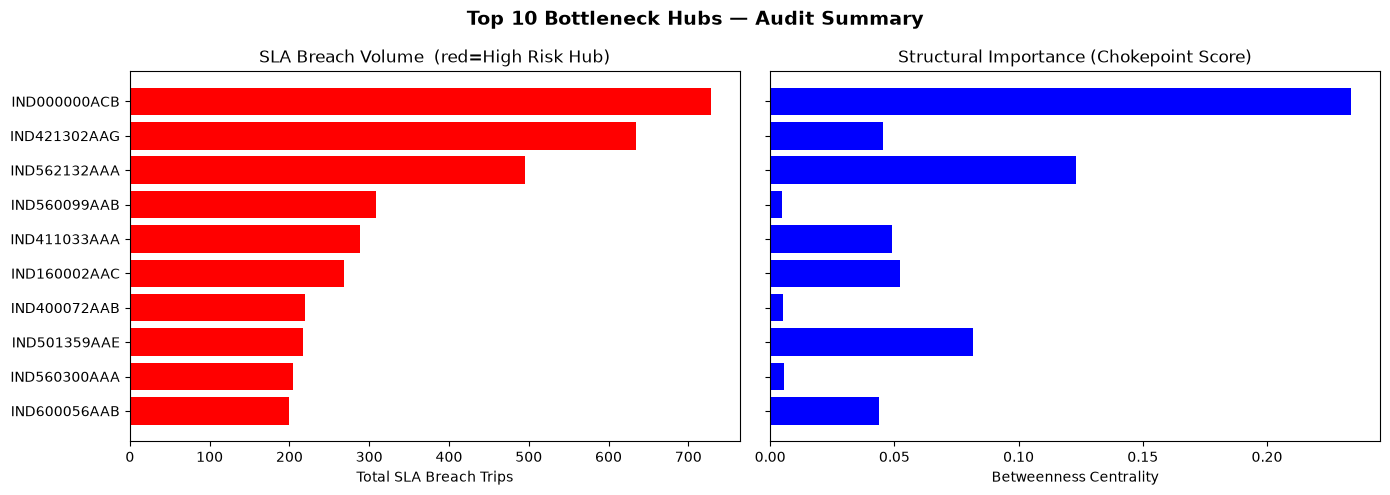

Saved: d:\Graph_ETA_Prediction\plots/bottleneck_hubs.png


In [10]:
# Plot the top 10 bottleneck hubs by SLA breach trips and betweenness centrality
PLOTS_DIR = os.path.join(BASE_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f"Plots will be saved to: {PLOTS_DIR}")

top_hubs = audit_df.head(10)
fig, axes = plt.subplots(1, 2, figsize=(14, 5),sharey=True)
fig.suptitle("Top 10 Bottleneck Hubs — Audit Summary", fontsize=14, fontweight="bold")

colors = ['red' if t == "High Risk" else 'red' for t in top_hubs["risk_tier"]]

axes[0].barh(top_hubs["hub_id"].astype(str), top_hubs["total_sla_breach_trips"], color=colors)
axes[0].set_xlabel("Total SLA Breach Trips")
axes[0].set_title("SLA Breach Volume  (red=High Risk Hub)")
axes[0].invert_yaxis()

axes[1].barh(top_hubs["hub_id"].astype(str), top_hubs["betweenness_centrality"], color="blue")
axes[1].set_xlabel("Betweenness Centrality")
axes[1].set_title("Structural Importance (Chokepoint Score)")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "bottleneck_hubs.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR}/bottleneck_hubs.png")


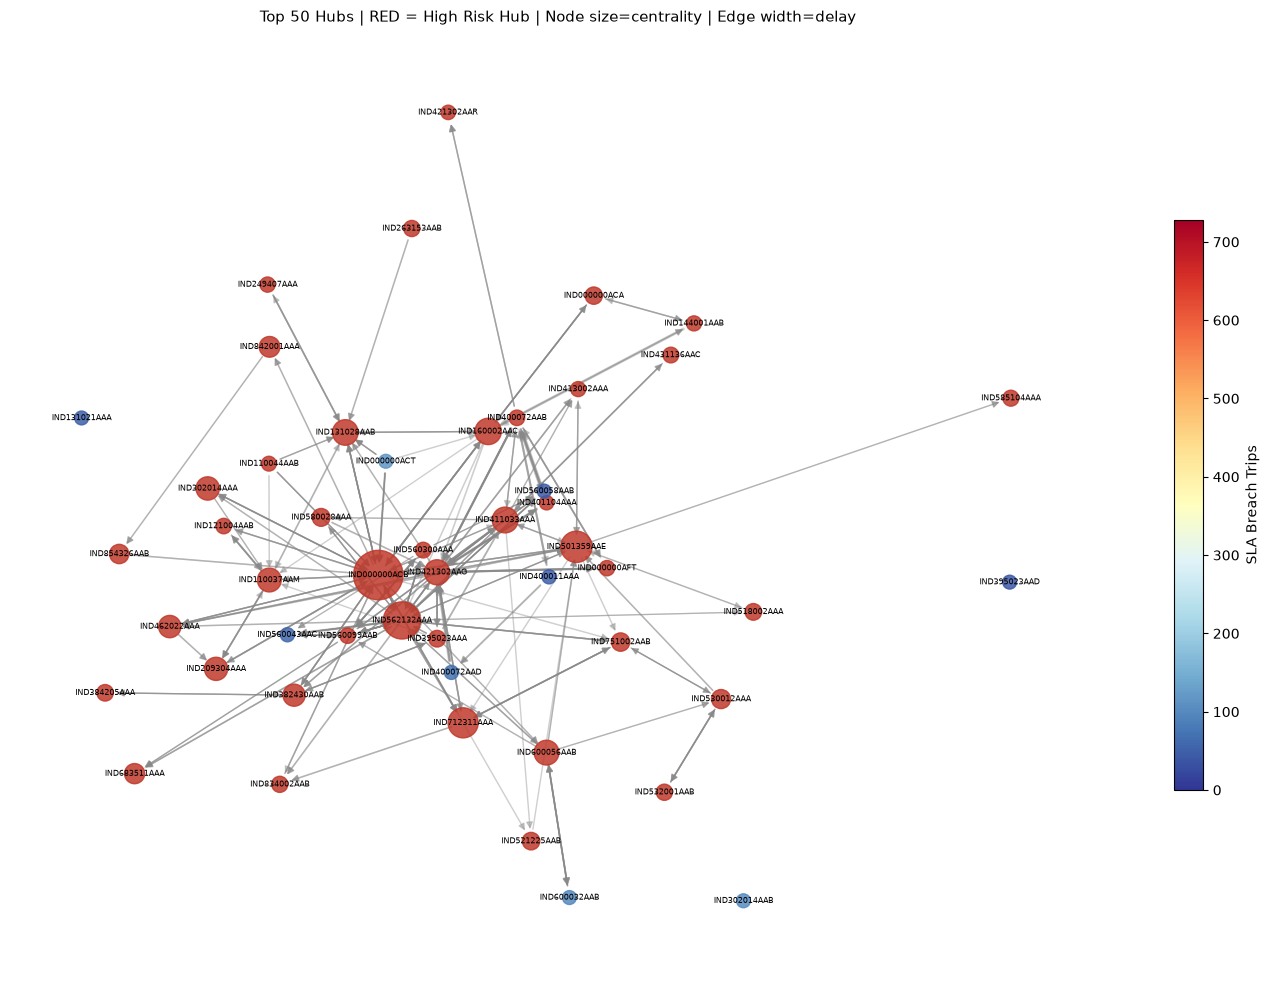

Saved: d:\Graph_ETA_Prediction\plots/network_graph.png


In [11]:
# Visualize the top 50 hubs as a network graph; node size = centrality, edge width = delay
top50_hubs = audit_df.head(50)["hub_id"].tolist()
subgraph   = G.subgraph(top50_hubs)

node_sizes  = [5000 * betweenness.get(n, 0.01) + 100 for n in subgraph.nodes()]
risk_map    = audit_df.set_index("hub_id")["risk_tier"].to_dict()
breach_map  = audit_df.set_index("hub_id")["total_sla_breach_trips"].to_dict()
max_breach  = max(breach_map.values())
node_colors = ["#C0392B" if risk_map.get(n) == "High Risk" else plt.cm.RdYlBu_r(breach_map.get(n, 0) / max_breach) for n in subgraph.nodes()]
edge_weights = [d.get("weight", 1.0) for _, _, d in subgraph.edges(data=True)]
max_w        = max(edge_weights)
edge_widths  = [0.5 + 2.5 * (w / max_w) for w in edge_weights]

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(subgraph, seed=26, k=0.8)
nx.draw_networkx_nodes(subgraph, pos, node_size=node_sizes, node_color=node_colors, alpha=0.85, ax=ax)
nx.draw_networkx_edges(subgraph, pos, width=edge_widths, edge_color="#888", alpha=0.4, arrows=True, arrowsize=10, ax=ax)
nx.draw_networkx_labels(subgraph, pos, font_size=6, ax=ax)
sm = plt.cm.ScalarMappable(cmap="RdYlBu_r", norm=mcolors.Normalize(vmin=0, vmax=max_breach))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="SLA Breach Trips", shrink=0.6)
ax.set_title("Top 50 Hubs | RED = High Risk Hub | Node size=centrality | Edge width=delay", fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "network_graph.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR}/network_graph.png")


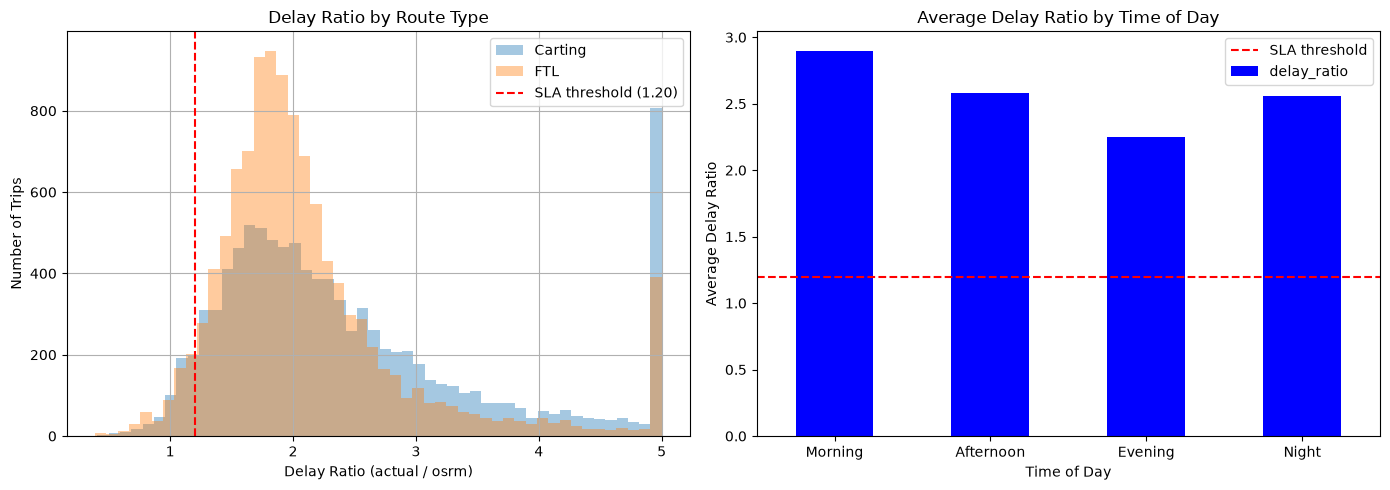

Saved: d:\Graph_ETA_Prediction\plots/delay_analysis.png


In [12]:
# Plot delay ratio distribution by route type and average delay by time of day
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for rtype, grp in trip_legs.groupby("route_type"):
    grp["delay_ratio"].clip(0, 5).hist(bins=50, alpha=0.4, label=rtype, ax=axes[0])
axes[0].axvline(1.2, color="red", linestyle="--", linewidth=1.5, label="SLA threshold (1.20)")
axes[0].set_xlabel("Delay Ratio (actual / osrm)")
axes[0].set_ylabel("Number of Trips")
axes[0].set_title("Delay Ratio by Route Type")
axes[0].legend()

tod_avg = trip_legs.groupby("time_of_day")["delay_ratio"].mean().reindex(
    ["Morning", "Afternoon", "Evening", "Night"])
tod_avg.plot(kind="bar", color='blue', ax=axes[1], rot=0)
axes[1].axhline(1.2, color="red", linestyle="--", linewidth=1.5, label="SLA threshold")
axes[1].set_xlabel("Time of Day")
axes[1].set_ylabel("Average Delay Ratio")
axes[1].set_title("Average Delay Ratio by Time of Day")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "delay_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR}/delay_analysis.png")


In [13]:
# Extract time features from timestamps and one-hot encode route type

df["od_start_time"] = pd.to_datetime(df["od_start_time"], errors="coerce")
df["od_hour"]    = df["od_start_time"].dt.hour.fillna(0).astype(int)
df["od_weekday"] = df["od_start_time"].dt.weekday.fillna(0).astype(int)

df["day"]     = df["trip_creation_time"].dt.day
df["month"]   = df["trip_creation_time"].dt.month
df["weekday"] = df["trip_creation_time"].dt.weekday

df["route_type_FTL"] = (df["route_type"].astype(str).str.strip().str.upper() == "FTL").astype(int)

print(df["route_type"].value_counts(dropna=False))
print(df["route_type_FTL"].value_counts(dropna=False))
print("\nShape after feature creation:", df.shape)

route_type
FTL        99660
Carting    45207
Name: count, dtype: int64
route_type_FTL
1    99660
0    45207
Name: count, dtype: int64

Shape after feature creation: (144867, 34)


In [14]:
# Build a 32-dimensional graph embedding vector for each hub using structural and delay stats

EMBEDDING_DIM = 16

out_dly = corridors_df.groupby("source_center_raw")["median_delay_ratio"].agg(
    ["mean", "max", "std", "count"]).fillna(0)
in_dly  = corridors_df.groupby("destination_center_raw")["median_delay_ratio"].agg(
    ["mean", "max", "std", "count"]).fillna(0)

out_p90 = corridors_df.groupby("source_center_raw")["p90_delay_ratio"].mean().fillna(1.0)
in_p90  = corridors_df.groupby("destination_center_raw")["p90_delay_ratio"].mean().fillna(1.0)

max_in_v  = max(in_degree.values())  or 1
max_out_v = max(out_degree.values()) or 1
max_b_v   = max(betweenness.values()) or 1
max_pr_v  = max(pagerank.values())   or 1

embeddings = {}
for node in G.nodes():
    node_s = str(node)
    b    = betweenness.get(node, 0)    / max_b_v
    ind  = in_degree.get(node, 0)      / max_in_v
    outd = out_degree.get(node, 0)     / max_out_v
    cl   = clustering.get(node, 0)
    pr   = pagerank.get(node, 0)       / max_pr_v
    dr   = outd / (ind + 1e-6)

    od_m  = out_dly.loc[node_s, "mean"]  if node_s in out_dly.index else 1.0
    od_x  = out_dly.loc[node_s, "max"]   if node_s in out_dly.index else 1.0
    od_sd = out_dly.loc[node_s, "std"]   if node_s in out_dly.index else 0.0
    od_v  = out_dly.loc[node_s, "count"] if node_s in out_dly.index else 0.0
    od_p  = out_p90.get(node_s, 1.0)

    id_m  = in_dly.loc[node_s, "mean"]   if node_s in in_dly.index else 1.0
    id_x  = in_dly.loc[node_s, "max"]    if node_s in in_dly.index else 1.0
    id_sd = in_dly.loc[node_s, "std"]    if node_s in in_dly.index else 0.0
    id_v  = in_dly.loc[node_s, "count"]  if node_s in in_dly.index else 0.0
    id_p  = in_p90.get(node_s, 1.0)


    embeddings[node_s] = np.array([
        b, ind, outd, cl, pr, dr,
        od_m, od_x, od_sd, od_v / 100, od_p,
        id_m, id_x, id_sd, id_v / 100, id_p,                         
    ], dtype=np.float32)

def get_emb(hub_raw_id):
    return embeddings.get(str(hub_raw_id), np.zeros(EMBEDDING_DIM, dtype=np.float32))

non_zero = sum(1 for k, v in embeddings.items() if np.any(v != 0))
print(f"Embeddings built: {len(embeddings):,} hubs × {EMBEDDING_DIM} dims")
print(f"Non-zero embeddings: {non_zero:,} / {len(embeddings):,}")


Embeddings built: 1,628 hubs × 16 dims
Non-zero embeddings: 1,628 / 1,628


In [15]:
# Attach source and destination hub embeddings as new columns to the main dataframe
src_cols = [f"src_emb_{i}" for i in range(EMBEDDING_DIM)]
dst_cols = [f"dst_emb_{i}" for i in range(EMBEDDING_DIM)]

src_embs = np.stack(df["source_center_raw"].apply(get_emb).values)
dst_embs = np.stack(df["destination_center_raw"].apply(get_emb).values)

for i, col in enumerate(src_cols): df[col] = src_embs[:, i]
for i, col in enumerate(dst_cols): df[col] = dst_embs[:, i]

src_categories = pd.Index(df_train["source_center_raw"].astype(str).unique())
dst_categories = pd.Index(df_train["destination_center_raw"].astype(str).unique())

src_mapping = {hub: i for i, hub in enumerate(src_categories)}
dst_mapping = {hub: i for i, hub in enumerate(dst_categories)}

df["source_center_enc"] = (df["source_center_raw"].astype(str).map(src_mapping).fillna(-1).astype(int))
df["destination_center_enc"] = (df["destination_center_raw"].astype(str).map(dst_mapping).fillna(-1).astype(int))

sample_emb = df[src_cols].values
print(f"Embedding check — non-zero src rows: {(sample_emb.sum(axis=1) != 0).sum():,} / {len(df):,}")
print("Any NaN in embeddings:", np.isnan(sample_emb).any())


Embedding check — non-zero src rows: 144,814 / 144,867
Any NaN in embeddings: False


In [16]:
# Encode time-of-day labels and assemble baseline and graph-enhanced feature sets for ML
le_time = LabelEncoder()
le_time.fit(df_train["time_of_day"].astype(str))

df["time_of_day_encoded"] = (df["time_of_day"].astype(str).map({ label: i for i, label in enumerate(le_time.classes_)}).fillna(-1).astype(int))

candidate_cols = [
    "source_center_enc", "destination_center_enc",
    "is_cutoff", "cutoff_factor",
    "actual_distance_to_destination",
    "osrm_time", "osrm_distance",
    "segment_osrm_time", "segment_osrm_distance",
    "time_of_day_encoded", "day", "month", "weekday",
    "route_type_FTL", "od_hour", "od_weekday",
]
baseline_features = [c for c in candidate_cols if c in df.columns]
enhanced_features = baseline_features + src_cols + dst_cols

X_base  = df[baseline_features].fillna(0)
X_graph = df[enhanced_features].fillna(0)
y       = df["actual_time"].values

X_train,   X_test   = X_base.loc[train_idx],  X_base.loc[test_idx]
X_train_g, X_test_g = X_graph.loc[train_idx], X_graph.loc[test_idx]
y_train,   y_test   = df.loc[train_idx, "actual_time"].values, df.loc[test_idx, "actual_time"].values
y_train_g, y_test_g = y_train, y_test 

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Baseline features: {len(baseline_features)}  |  Graph features: {len(enhanced_features)}")


Train: 115,939  |  Test: 28,928
Baseline features: 16  |  Graph features: 48


In [17]:
# Shared metric: % of predictions within `tol` of the true value (used by RF, CatBoost, XGBoost, OSRM)
def accuracy_within_tolerance(y_true, y_pred, tol=0.15):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    ape = np.abs((y_true - y_pred) / np.maximum(y_true, 1e-6))
    return (ape <= tol).mean() * 100


## 1.RandomForest Model

In [18]:
# Train a Random Forest on baseline features and measure MAE and 15%-accuracy
rf_baseline = RandomForestRegressor(n_estimators=250,max_depth=8, random_state=26, n_jobs=-1)
rf_baseline.fit(X_train, y_train)
y_pred_rf = rf_baseline.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test,y_pred_rf)
rf_acc15 = accuracy_within_tolerance(y_test, y_pred_rf)

# Train a Random Forest with graph embedding features and compare improvement over baseline
rf_graph = RandomForestRegressor(n_estimators=250,max_depth=8, random_state=26, n_jobs=-1)
rf_graph.fit(X_train_g, y_train_g)
y_pred_rf_graph = rf_graph.predict(X_test_g)

rf_graph_mae = mean_absolute_error(y_test_g, y_pred_rf_graph)
rf_graph_r2 = r2_score(y_test_g,y_pred_rf_graph)
rf_graph_acc15 = accuracy_within_tolerance(y_test_g, y_pred_rf_graph)

print("RF BASELINE")
print(f"  MAE:          {rf_mae:.2f} min")
print(f"  r2:          {rf_r2:.4f}")
print(f"  Acc@15%:      {rf_acc15:.1f}%")
print("RF + GRAPH EMBEDDINGS")
print(f"  MAE:          {rf_graph_mae:.2f} min")
print(f"  r2:          {rf_graph_r2:.4f}")
print(f"  Acc@15%:      {rf_graph_acc15:.1f}%")
print(f"Improvement over RF Baseline: MAE {rf_mae - rf_graph_mae:+.2f} min")


RF BASELINE
  MAE:          47.40 min
  r2:          0.9772
  Acc@15%:      47.1%
RF + GRAPH EMBEDDINGS
  MAE:          44.43 min
  r2:          0.9805
  Acc@15%:      48.8%
Improvement over RF Baseline: MAE +2.97 min


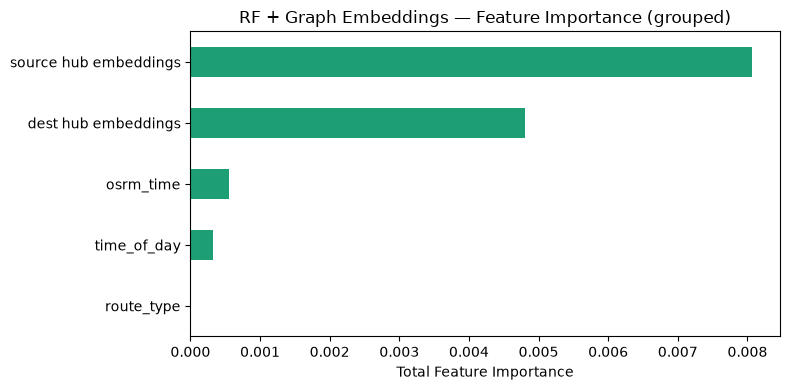

Saved: d:\Graph_ETA_Prediction\plots/rf_graph_importance.png


In [19]:
# Plot grouped feature importances for the RF + Graph model
rf_g_imp = pd.Series(rf_graph.feature_importances_, index=enhanced_features)
grouped_rf = {
    "osrm_time":             rf_g_imp.get("osrm_time", 0),
    "time_of_day":           rf_g_imp.get("time_of_day_encoded", 0),
    "route_type":            rf_g_imp.get("route_type_FTL", 0),
    "source hub embeddings": rf_g_imp[src_cols].sum(),
    "dest hub embeddings":   rf_g_imp[dst_cols].sum(),
}
fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(grouped_rf).sort_values().plot(kind="barh", color="#1D9E75", ax=ax)
ax.set_xlabel("Total Feature Importance")
ax.set_title("RF + Graph Embeddings — Feature Importance (grouped)")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "rf_graph_importance.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR}/rf_graph_importance.png")

# 2.CatBoast

In [20]:
# Train a CatBoost model on baseline features and measure MAE and 15%-accuracy
cb_baseline = CatBoostRegressor(
    iterations=250,
    depth=8,
    learning_rate=0.05,
    random_seed=26,
    thread_count=-1,
    verbose=False
)

cb_baseline.fit(X_train, y_train)
y_pred_cb = cb_baseline.predict(X_test)

cb_mae = mean_absolute_error(y_test, y_pred_cb)
cb_r2 = r2_score(y_test, y_pred_cb)
cb_acc15 = accuracy_within_tolerance(y_test, y_pred_cb)

# Train a CatBoost model with graph embedding features and compare improvement over baseline
cb_graph = CatBoostRegressor(
    iterations=250,
    depth=8,
    learning_rate=0.05,
    random_seed=26,
    thread_count=-1,
    verbose=False
)

cb_graph.fit(X_train_g, y_train_g)
y_pred_cb_graph = cb_graph.predict(X_test_g)

cb_graph_mae = mean_absolute_error(y_test_g, y_pred_cb_graph)
cb_graph_r2 =  r2_score(y_test_g, y_pred_cb_graph)
cb_graph_acc15 = accuracy_within_tolerance(y_test_g, y_pred_cb_graph)

print("CB BASELINE")
print(f"  MAE:          {cb_mae:.2f} min")
print(f"  r2:          {cb_r2:.4f}")
print(f"  Acc@15%:      {cb_acc15:.1f}%")
print("CB + GRAPH EMBEDDINGS")
print(f"  MAE:          {cb_graph_mae:.2f} min")
print(f"  r2:          {cb_graph_r2:.4f}")
print(f"  Acc@15%:      {cb_graph_acc15:.1f}%")
print(f"Improvement over CB Baseline: MAE {cb_mae - cb_graph_mae:+.2f} min")


CB BASELINE
  MAE:          44.38 min
  r2:          0.9802
  Acc@15%:      49.5%
CB + GRAPH EMBEDDINGS
  MAE:          40.16 min
  r2:          0.9837
  Acc@15%:      55.1%
Improvement over CB Baseline: MAE +4.21 min


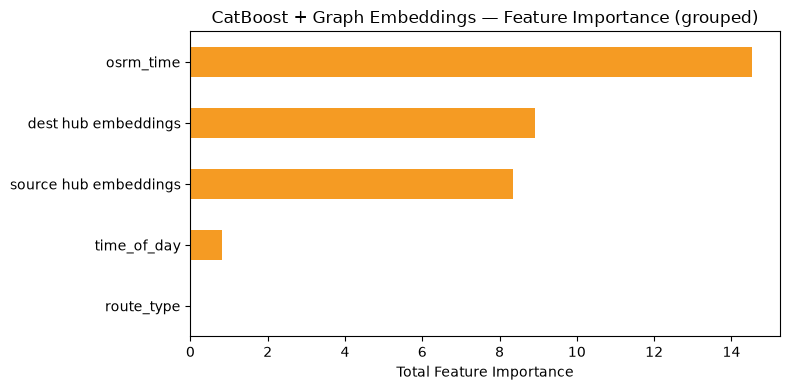

Saved: d:\Graph_ETA_Prediction\plots/cb_graph_importance.png


In [21]:
# Plot grouped feature importances for the CatBoost + Graph model
cb_g_imp = pd.Series(cb_graph.get_feature_importance(), index=enhanced_features)
grouped_cb = {
    "osrm_time":             cb_g_imp.get("osrm_time", 0),
    "time_of_day":           cb_g_imp.get("time_of_day_encoded", 0),
    "route_type":            cb_g_imp.get("route_type_FTL", 0),
    "source hub embeddings": cb_g_imp[src_cols].sum(),
    "dest hub embeddings":   cb_g_imp[dst_cols].sum(),
}
fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(grouped_cb).sort_values().plot(kind="barh", color="#F59B23", ax=ax)
ax.set_xlabel("Total Feature Importance")
ax.set_title("CatBoost + Graph Embeddings — Feature Importance (grouped)")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "cb_graph_importance.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR}/cb_graph_importance.png")


# 3. XGBoast

XGBOOST BASELINE
  MAE:          41.51 min
  r2:          0.9812
  Acc@15%:      54.9%
XGBOOST + GRAPH EMBEDDINGS
  MAE:          37.74 min
  r2:          0.9835
  Acc@15%:      61.4%
Improvement over XGB Baseline: MAE +3.76 min


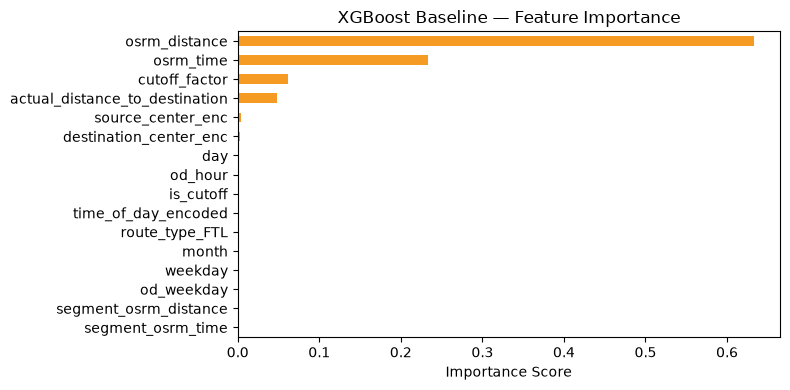

Saved: d:\Graph_ETA_Prediction\plots/xgb_baseline_importance.png


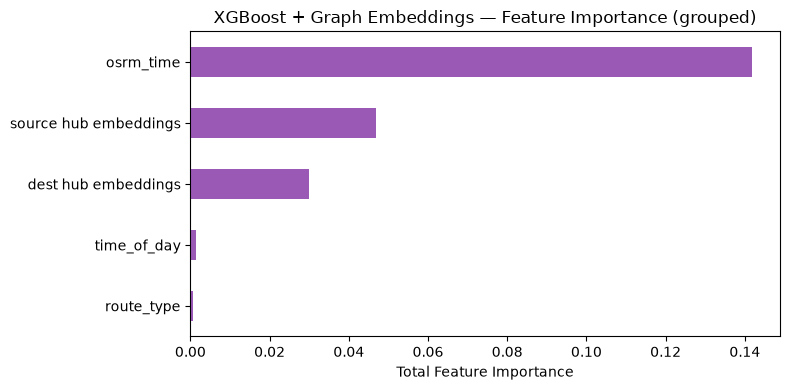

Saved: d:\Graph_ETA_Prediction\plots/xgb_graph_importance.png


In [22]:
# Train an XGBoost model on baseline features and plot feature importances
xgb_baseline = xgb.XGBRegressor(
    n_estimators=250, learning_rate=0.05, max_depth=8,
    subsample=0.8, colsample_bytree=0.8,
    random_state=26, n_jobs=-1, verbosity=0,
)
xgb_baseline.fit(X_train, y_train)
y_pred_xgb = xgb_baseline.predict(X_test)

xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test,y_pred_xgb)
xgb_acc15 = accuracy_within_tolerance(y_test, y_pred_xgb)

xgb_graph = xgb.XGBRegressor(
    n_estimators=250, learning_rate=0.05, max_depth=8,
    subsample=0.8, colsample_bytree=0.8,
    random_state=26, n_jobs=-1, verbosity=0,
)
xgb_graph.fit(X_train_g, y_train_g)
y_pred_xgb_graph = xgb_graph.predict(X_test_g)

xgb_graph_mae = mean_absolute_error(y_test_g, y_pred_xgb_graph)
xgb_graph_r2 = r2_score(y_test_g,y_pred_xgb_graph)
xgb_graph_acc15 = accuracy_within_tolerance(y_test_g, y_pred_xgb_graph)

print("XGBOOST BASELINE")
print(f"  MAE:          {xgb_mae:.2f} min")
print(f"  r2:          {xgb_r2:.4f}")
print(f"  Acc@15%:      {xgb_acc15:.1f}%")

print("XGBOOST + GRAPH EMBEDDINGS")
print(f"  MAE:          {xgb_graph_mae:.2f} min")
print(f"  r2:          {xgb_graph_r2:.4f}")
print(f"  Acc@15%:      {xgb_graph_acc15:.1f}%")
print(f"Improvement over XGB Baseline: MAE {xgb_mae - xgb_graph_mae:+.2f} min")


fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(xgb_baseline.feature_importances_, index=baseline_features).sort_values().plot(
    kind="barh", color="#F59B23", ax=ax)
ax.set_title("XGBoost Baseline — Feature Importance")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "xgb_baseline_importance.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR}/xgb_baseline_importance.png")

xgb_g_imp = pd.Series(xgb_graph.feature_importances_, index=enhanced_features)
grouped_xgb = {
    "osrm_time":             xgb_g_imp.get("osrm_time", 0),
    "time_of_day":           xgb_g_imp.get("time_of_day_encoded", 0),
    "route_type":            xgb_g_imp.get("route_type_FTL", 0),
    "source hub embeddings": xgb_g_imp[src_cols].sum(),
    "dest hub embeddings":   xgb_g_imp[dst_cols].sum(),
}
fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(grouped_xgb).sort_values().plot(kind="barh", color="#9B59B6", ax=ax)
ax.set_xlabel("Total Feature Importance")
ax.set_title("XGBoost + Graph Embeddings — Feature Importance (grouped)")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "xgb_graph_importance.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR}/xgb_graph_importance.png")


In [23]:
osrm_mae = mean_absolute_error(y_test, X_test['osrm_time'])
osrm_r2 = r2_score(y_test, X_test['osrm_time'])
osrm_acc15 = accuracy_within_tolerance(y_test, X_test['osrm_time'])
print("OSRM Scores")
print(f"  MAE:         {osrm_mae:.2f} min")
print(f"  r2:          {osrm_r2:.4f}")
print(f"  Acc@15%:     {osrm_acc15:.1f}%")


OSRM Scores
  MAE:         201.90 min
  r2:          0.6386
  Acc@15%:     4.3%


7-MODEL COMPARISON SUMMARY
Metric             OSRM         RF         CB       XGBoost   RF+Graph   CB_Graph   XGB+Graph
-----------------------------------------------------------------------------------------------
MAE (min)        201.90      47.40      44.38         41.51      44.43      40.16       37.74
Acc@15% (%)        4.26      47.11      49.48         54.85      48.76      55.08       61.45


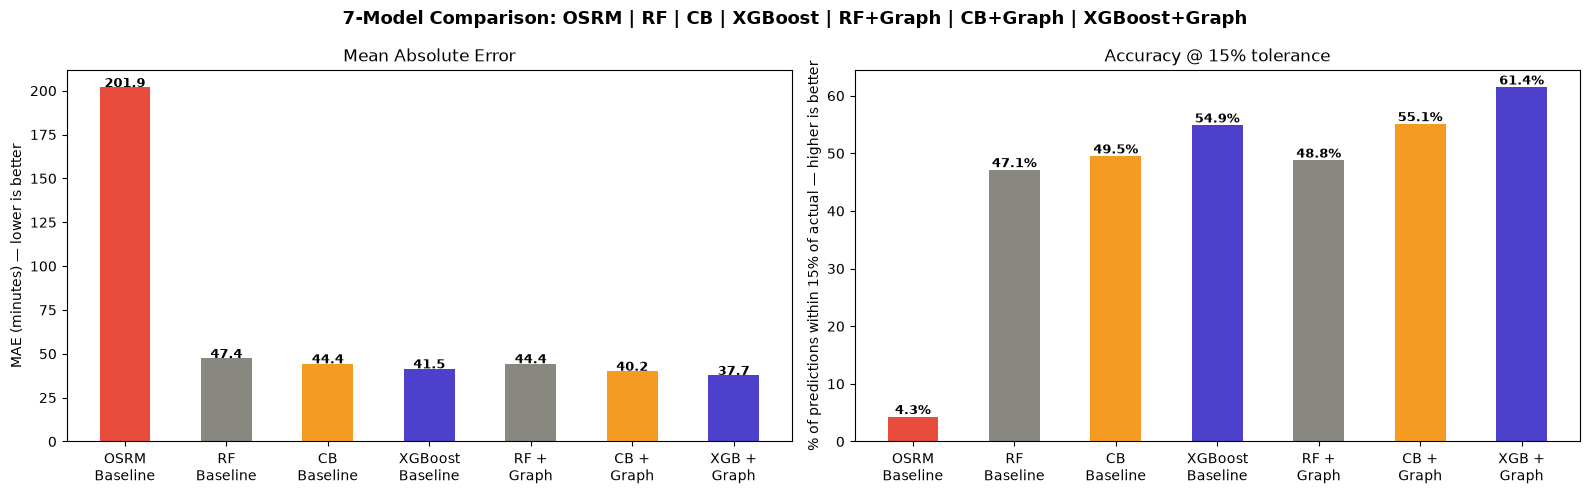

Saved: d:\Graph_ETA_Prediction\plots/model_comparison.png

Best graph-enhanced model by MAE: XGB+Graph (37.74 min)


In [24]:
# Print and plot a side-by-side comparison of all seven models on MAE and 15%-accuracy
def _fmt(v): return f"{v:.2f}" if v is not None else "N/A"
print("7-MODEL COMPARISON SUMMARY")
print("=" * 95)
print(f"{'Metric':<12} {'OSRM':>10} {'RF':>10} {'CB':>10} {'XGBoost':>13} {'RF+Graph':>10} {'CB_Graph':>10} {'XGB+Graph':>11}")
print("-" * 95)
print(f"{'MAE (min)':<14} {_fmt(osrm_mae):>8} {_fmt(rf_mae):>10} {_fmt(cb_mae):>10} {_fmt(xgb_mae):>13} {_fmt(rf_graph_mae):>10} {_fmt(cb_graph_mae):>10} {_fmt(xgb_graph_mae):>11}")
print(f"{'Acc@15% (%)':<14} {_fmt(osrm_acc15):>8} {_fmt(rf_acc15):>10} {_fmt(cb_acc15):>10} {_fmt(xgb_acc15):>13} {_fmt(rf_graph_acc15):>10} {_fmt(cb_graph_acc15):>10} {_fmt(xgb_graph_acc15):>11}")

model_names = ["OSRM\nBaseline", "RF\nBaseline", "CB\nBaseline", "XGBoost\nBaseline", "RF +\nGraph","CB +\nGraph", "XGB +\nGraph"]
bar_colors  = ["#E74C3C", "#888780", "#F59B23", "#4C40CC", "#888780", "#F59B23", "#4C40CC"]

mae_vals = [osrm_mae, rf_mae, cb_mae, xgb_mae, rf_graph_mae, cb_graph_mae, xgb_graph_mae]
acc_vals = [osrm_acc15, rf_acc15, cb_acc15, xgb_acc15, rf_graph_acc15, cb_graph_acc15, xgb_graph_acc15]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("7-Model Comparison: OSRM | RF | CB | XGBoost | RF+Graph | CB+Graph | XGBoost+Graph",
             fontsize=13, fontweight="bold")

b0 = axes[0].bar(model_names, mae_vals, color=bar_colors, width=0.5)
axes[0].set_ylabel("MAE (minutes) — lower is better")
axes[0].set_title("Mean Absolute Error")
for bar, v in zip(b0, mae_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.2, f"{v:.1f}",
                 ha="center", fontweight="bold", fontsize=9)

b1 = axes[1].bar(model_names, acc_vals, color=bar_colors, width=0.5)
axes[1].set_ylabel("% of predictions within 15% of actual — higher is better")
axes[1].set_title("Accuracy @ 15% tolerance")
for bar, v in zip(b1, acc_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v:.1f}%",
                 ha="center", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "model_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR}/model_comparison.png")

graph_maes = {"RF+Graph": rf_graph_mae, "CB+Graph": cb_graph_mae, "XGB+Graph": xgb_graph_mae}
best_model_name = min(graph_maes, key=graph_maes.get)
print(f"\nBest graph-enhanced model by MAE: {best_model_name} ({graph_maes[best_model_name]:.2f} min)")


In [25]:
# Label each trip as High/Low Risk Hub based on source centrality and outbound delay
df["actual_time_col"] = df["actual_time"] if "actual_time" in df.columns else y
df["delay_ratio"]     = df["actual_time_col"] / np.maximum(df["osrm_time"], 1e-6)
df["route_type_str"]  = np.where(df.get("route_type_FTL", pd.Series(0, index=df.index)) == 1,
                                  "FTL", "Carting")

df["source_centrality"] = df["source_center_raw"].map(betweenness).fillna(0)
centrality_threshold    = df["source_centrality"].median()

df["src_out_delay"] = df["source_center_raw"].map(
    corridors_df.groupby("source_center_raw")["median_delay_ratio"].mean()).fillna(1.0)

df["risk_profile"] = "Low Risk Hub"
df.loc[
    (df["source_centrality"] > centrality_threshold) &
    (df["src_out_delay"] > 1.1),
    "risk_profile"
] = "High Risk Hub"

print(f"Centrality threshold: {centrality_threshold:.6f}")
print(df["risk_profile"].value_counts())
print("\nHigh Risk Hub confirmed:", (df["risk_profile"] == "High Risk Hub").sum() > 0)


Centrality threshold: 0.013083
risk_profile
Low Risk Hub     72718
High Risk Hub    72149
Name: count, dtype: int64

High Risk Hub confirmed: True


In [26]:
# Fit a shallow decision tree to explain FTL vs Carting classification rules
df["is_FTL"] = (df["route_type_str"] == "FTL").astype(int)

dt_features = ["osrm_time", "time_of_day_encoded", "source_centrality"]
X_dt = df[dt_features].fillna(0)
y_dt = df["is_FTL"]

dt_model = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42)
dt_model.fit(X_dt, y_dt)

print("DECISION TREE RULES (FTL vs Carting):")
print(export_text(dt_model, feature_names=dt_features))


DECISION TREE RULES (FTL vs Carting):
|--- osrm_time <= 69.50
|   |--- osrm_time <= 15.50
|   |   |--- osrm_time <= 14.50
|   |   |   |--- class: 0
|   |   |--- osrm_time >  14.50
|   |   |   |--- class: 0
|   |--- osrm_time >  15.50
|   |   |--- osrm_time <= 41.50
|   |   |   |--- class: 0
|   |   |--- osrm_time >  41.50
|   |   |   |--- class: 0
|--- osrm_time >  69.50
|   |--- osrm_time <= 103.50
|   |   |--- source_centrality <= 0.00
|   |   |   |--- class: 0
|   |   |--- source_centrality >  0.00
|   |   |   |--- class: 1
|   |--- osrm_time >  103.50
|   |   |--- source_centrality <= 0.01
|   |   |   |--- class: 1
|   |   |--- source_centrality >  0.01
|   |   |   |--- class: 1



In [27]:
# Compare average delivery time and median delay ratio between FTL and Carting per risk tier
tradeoff = df.groupby(["risk_profile", "route_type_str"]).agg(
    avg_actual_time=("actual_time_col", "mean"),
    median_delay_ratio=("delay_ratio", "median"),
    trip_count=("actual_time_col", "count")
).reset_index().round(2)

print("FTL vs CARTING: TIME-COST TRADE-OFF")
print("=" * 65)
print(tradeoff.to_string(index=False))
print("\n  delay_ratio > 1.0 = trips take longer than OSRM predicted")


FTL vs CARTING: TIME-COST TRADE-OFF
 risk_profile route_type_str  avg_actual_time  median_delay_ratio  trip_count
High Risk Hub        Carting            67.95                1.81       11571
High Risk Hub            FTL           811.85                1.85       60578
 Low Risk Hub        Carting            71.56                1.96       33636
 Low Risk Hub            FTL           205.35                1.83       39082

  delay_ratio > 1.0 = trips take longer than OSRM predicted


In [28]:
# Calculate SLA breach rate and estimated revenue at risk per hub-risk and route combination
PENALTY_PER_BREACH_RS = 500
df["is_sla_breach"] = (df["delay_ratio"] > 1.20).astype(int)

revenue_risk = df.groupby(["risk_profile", "route_type_str"]).agg(
    total_trips=("is_sla_breach", "count"),
    breach_trips=("is_sla_breach", "sum")
).reset_index()
revenue_risk["breach_rate_%"]      = (revenue_risk["breach_trips"] / revenue_risk["total_trips"] * 100).round(1)
revenue_risk["revenue_at_risk_Rs"] = revenue_risk["breach_trips"] * PENALTY_PER_BREACH_RS

print(f"SLA BREACH RATES (Rs {PENALTY_PER_BREACH_RS}/breach penalty)")
print(revenue_risk.round(0).to_string(index=False))


SLA BREACH RATES (Rs 500/breach penalty)
 risk_profile route_type_str  total_trips  breach_trips  breach_rate_%  revenue_at_risk_Rs
High Risk Hub        Carting        11571         10438           90.0             5219000
High Risk Hub            FTL        60578         59651           98.0            29825500
 Low Risk Hub        Carting        33636         30541           91.0            15270500
 Low Risk Hub            FTL        39082         36272           93.0            18136000


In [29]:
# Tag each corridor with a recommended action: switch to FTL, hub upgrade, or monitor
corridor_summary = corridors_df.copy()
corridor_summary["recommended_action"] = corridor_summary.apply(
    lambda r: (
        "Switch to FTL"    if r["route_type"] == "Carting" and r["median_delay_ratio"] > 1.5
        else "Hub upgrade" if r["median_delay_ratio"] > 2.0
        else "Monitor"
    ), axis=1
)

top_breach_corridors = (
    corridor_summary[(corridor_summary["median_delay_ratio"] > 1.20) &(corridor_summary["total_trips"] >= 5)]
    .sort_values("median_delay_ratio", ascending=False)
    .head(20)
)

print("TOP 20 CHRONIC DELAY CORRIDORS:")
print(top_breach_corridors[[
    "source_center_raw","destination_center_raw","route_type",
    "time_of_day","median_delay_ratio","total_trips","recommended_action"
]].reset_index(drop=True).to_string(index=False))


TOP 20 CHRONIC DELAY CORRIDORS:
source_center_raw destination_center_raw route_type time_of_day  median_delay_ratio  total_trips recommended_action
     IND208012AAA           IND209304AAA    Carting       Night           36.666667            9      Switch to FTL
     IND792121AAB           IND786181AAC    Carting     Morning           33.586207            7      Switch to FTL
     IND212402AAA           IND211002AAB    Carting       Night           29.250000           11      Switch to FTL
     IND416606AAA           IND416510AAA    Carting       Night           27.044444            7      Switch to FTL
     IND802212AAA           IND821115AAB        FTL       Night           23.738095            7        Hub upgrade
     IND425405AAA           IND424006AAA        FTL       Night           21.260870           11        Hub upgrade
     IND209801AAA           IND209304AAA    Carting       Night           20.757576            5      Switch to FTL
     IND208017AAA           IND209304AAA

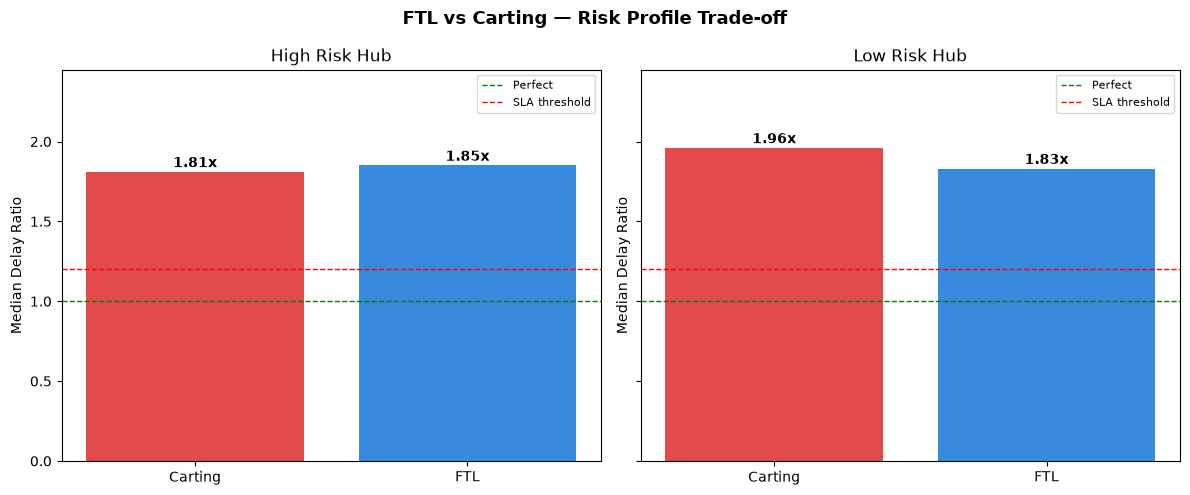

Saved: d:\Graph_ETA_Prediction\plots/ftl_carting_tradeoff.png


In [30]:
# Bar chart comparing median delay ratio for FTL vs Carting split by hub risk profile
risk_levels  = ["High Risk Hub", "Low Risk Hub"]
route_colors = {"FTL": "#378ADD", "Carting": "#E24B4A"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5),sharey=True)
fig.suptitle("FTL vs Carting — Risk Profile Trade-off", fontsize=13, fontweight="bold")

for ax_idx, risk_level in enumerate(risk_levels):
    subset = tradeoff[tradeoff["risk_profile"] == risk_level]
    if subset.empty:
        axes[ax_idx].set_title(f"{risk_level} (no data)")
        axes[ax_idx].text(0.5, 0.5, "No data", ha="center", va="center",
                          transform=axes[ax_idx].transAxes)
        continue
    bars = axes[ax_idx].bar(
        subset["route_type_str"], subset["median_delay_ratio"],
        color=[route_colors.get(rt, "#888") for rt in subset["route_type_str"]]
    )
    axes[ax_idx].axhline(1.0, color="green", linestyle="--", linewidth=1, label="Perfect")
    axes[ax_idx].axhline(1.2, color="red",   linestyle="--", linewidth=1, label="SLA threshold")
    axes[ax_idx].set_title(risk_level)
    axes[ax_idx].set_ylabel("Median Delay Ratio")
    axes[ax_idx].set_ylim(0, tradeoff["median_delay_ratio"].max() * 1.25)
    axes[ax_idx].legend(fontsize=8)
    for bar, val in zip(bars, subset["median_delay_ratio"]):
        axes[ax_idx].text(bar.get_x() + bar.get_width()/2, val + 0.03,
                          f"{val:.2f}x", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "ftl_carting_tradeoff.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR}/ftl_carting_tradeoff.png")


In [31]:
# Summarize the top 5 bottleneck hubs with breach share and estimated revenue at risk
top5 = audit_df.head(5)[["hub_id","in_degree","out_degree",
                          "betweenness_centrality","total_sla_breach_trips","risk_tier"]].copy()

total_breaches = audit_df["total_sla_breach_trips"].sum()
top5["% of total breaches"]          = (top5["total_sla_breach_trips"] / total_breaches * 100).round(1)
top5["estimated_revenue_at_risk_Rs"] = top5["total_sla_breach_trips"] * PENALTY_PER_BREACH_RS

print("TOP 5 BOTTLENECK HUBS")
print(top5.round(3).to_string(index=False))
top5_share = top5["total_sla_breach_trips"].sum() / total_breaches * 100
print(f"\nTotal breach trips: {int(total_breaches):,}  |  Top-5 share: {top5_share:.1f}%")


TOP 5 BOTTLENECK HUBS
      hub_id  in_degree  out_degree  betweenness_centrality  total_sla_breach_trips risk_tier  % of total breaches  estimated_revenue_at_risk_Rs
IND000000ACB        101         108                   0.234                   728.0 High Risk                  4.5                      364000.0
IND421302AAG         67          81                   0.046                   635.0 High Risk                  3.9                      317500.0
IND562132AAA         78          86                   0.123                   495.0 High Risk                  3.0                      247500.0
IND560099AAB         30          41                   0.005                   308.0 High Risk                  1.9                      154000.0
IND411033AAA         38          43                   0.049                   289.0 High Risk                  1.8                      144500.0

Total breach trips: 16,357  |  Top-5 share: 15.0%


In [32]:
network_median_breach_rate = df["is_sla_breach"].mean()
top5_for_recovery = audit_df.head(5)
breaches_recovered = 0

for _, hub in top5_for_recovery.iterrows():
    current  = hub["total_sla_breach_trips"]
    expected = current * network_median_breach_rate
    breaches_recovered += max(0, current - expected)

total_current_breaches = df["is_sla_breach"].sum()
reduction_pct     = (breaches_recovered / total_current_breaches * 100) if total_current_breaches > 0 else 0
revenue_recovered = breaches_recovered * PENALTY_PER_BREACH_RS

print("ESTIMATED IMPACT OF UPGRADING TOP 5 HUBS")
print(f"  Network median breach rate  : {network_median_breach_rate*100:.1f}%")
print(f"  SLA breaches recovered      : {int(breaches_recovered):,}")
print(f"  Reduction in late deliveries: {reduction_pct:.1f}%")
print(f"  Revenue recovered           : Rs {revenue_recovered:,.0f}")


ESTIMATED IMPACT OF UPGRADING TOP 5 HUBS
  Network median breach rate  : 94.5%
  SLA breaches recovered      : 134
  Reduction in late deliveries: 0.1%
  Revenue recovered           : Rs 67,490


In [33]:
def _m(v, unit=""):
    return f"{v:.1f}{unit}" if v is not None else "N/A"

hub1, hub2, hub3 = top5.iloc[0], top5.iloc[1], top5.iloc[2]

graph_maes = {"RF + Graph": rf_graph_mae, "CatBoost + Graph": cb_graph_mae, "XGBoost + Graph": xgb_graph_mae}
best_model_name = min(graph_maes, key=graph_maes.get)
best_model_mae  = graph_maes[best_model_name]

memo = f"""
╔══════════════════════════════════════════════════════════════╗
║      NETWORK OPERATIONS STRATEGY MEMO — DELHIVERY            ║
║      Graph-Based ETA Intelligence — Key Findings             ║
╚══════════════════════════════════════════════════════════════╝

RE:   Bottleneck Hubs, Corridor Interventions & Revenue Impact

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXECUTIVE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
OSRM underestimates delivery time on over {(df["delay_ratio"] > 1.0).mean()*100:.0f}% of corridors.
{best_model_name} is the best-performing model, with MAE {best_model_mae:.1f} min.
High-Risk Hubs identified: {( df.loc[ df["risk_profile"] == "High Risk Hub","source_center_raw"].nunique())} unique hubs flagged.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TOP 5 BOTTLENECK HUBS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━"""

for i, (_, hub) in enumerate(top5.iterrows(), 1):
    memo += f"""
{i}. {hub["hub_id"]}  [{hub["risk_tier"]}]
   SLA breach trips : {int(hub["total_sla_breach_trips"]):,} ({hub["% of total breaches"]}% of network total)
   Connections      : {int(hub["in_degree"])} in / {int(hub["out_degree"])} out
   Chokepoint score : {hub["betweenness_centrality"]:.4f}
   Revenue at risk  : Rs {hub["estimated_revenue_at_risk_Rs"]:,.0f}"""

memo += f"""

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RECOMMENDED INTERVENTIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. FACILITY UPGRADE at {hub1["hub_id"]} — highest breach volume + centrality.
2. PARALLEL ROUTE out of {hub2["hub_id"]} — high delay on evening shifts.
3. ROUTE TYPE SWITCH at {hub3["hub_id"]} — shift Carting trips to FTL.
4. NIGHT SHIFT CAPACITY across all top-5 hubs.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
QUANTIFIED IMPACT: IF TOP 3 HUBS ARE UPGRADED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Breaches recovered           : {int(breaches_recovered):,}
  Reduction in late deliveries : {reduction_pct:.1f}%
  Revenue recovered            : Rs {revenue_recovered:,.0f}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MODEL PERFORMANCE COMPARISON
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RF Baseline            : MAE {_m(rf_mae," min"):<10}
  CatBoost Baseline      : MAE {_m(cb_mae," min"):<10}
  XGBoost Baseline       : MAE {_m(xgb_mae," min"):<10}
  RF + Graph Embeddings  : MAE {_m(rf_graph_mae," min"):<10}
  CatBoost + Graph Embeds: MAE {_m(cb_graph_mae," min"):<10}
  XGBoost + Graph Embeds : MAE {_m(xgb_graph_mae," min"):<10}
"""

# print(memo)


In [34]:
# Save the memo, all dataframes, model artifacts, and embeddings to disk
with open("strategy_memo.txt", "w", encoding="utf-8") as f:
    f.write(memo)

import pickle, os

save_dir = "app_data"
os.makedirs(save_dir, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

audit_df.to_csv(f"{save_dir}/audit_df.csv", index=False)
corridors_df.to_csv(f"{save_dir}/corridors_df.csv", index=False)
top_breach_corridors.to_csv(f"{save_dir}/top_breach_corridors.csv", index=False)
revenue_risk.to_csv(f"{save_dir}/revenue_risk.csv", index=False)

results = {
    "rf_mae": rf_mae, "rf_acc15": rf_acc15,
    "cb_mae": cb_mae, "cb_acc15": cb_acc15,
    "xgb_mae": xgb_mae, "xgb_acc15": xgb_acc15,
    "rf_graph_mae": rf_graph_mae, "rf_graph_acc15": rf_graph_acc15,
    "cb_graph_mae": cb_graph_mae, "cb_graph_acc15": cb_graph_acc15,
    "xgb_graph_mae": xgb_graph_mae, "xgb_graph_acc15": xgb_graph_acc15,
    "best_graph_model": best_model_name,
    "breaches_recovered": breaches_recovered,
    "reduction_pct": reduction_pct,
    "revenue_recovered": revenue_recovered,
    "total_current_breaches": int(total_current_breaches),
    "memo": memo,
}
with open(f"{save_dir}/results.pkl", "wb") as f:
    pickle.dump(results, f)

# All three graph models are saved (previously only xgb_graph was) so the
# Streamlit app can load/compare any of them, or the best one via
# results["best_graph_model"].
with open(f"{save_dir}/rf_graph_model.pkl", "wb") as f:
    pickle.dump(rf_graph, f)
with open(f"{save_dir}/cb_graph_model.pkl", "wb") as f:
    pickle.dump(cb_graph, f)
with open(f"{save_dir}/xgb_graph_model.pkl", "wb") as f:
    pickle.dump(xgb_graph, f)
with open(f"{save_dir}/enhanced_features.pkl", "wb") as f:
    pickle.dump(enhanced_features, f)
with open(f"{save_dir}/embeddings.pkl", "wb") as f:
    pickle.dump(embeddings, f)
with open(f"{save_dir}/le_time.pkl", "wb") as f:
    pickle.dump(le_time, f)

print("All outputs saved:")
for fn in ["strategy_memo.txt",
           f"{PLOTS_DIR}/bottleneck_hubs.png", f"{PLOTS_DIR}/network_graph.png",
           f"{PLOTS_DIR}/delay_analysis.png", f"{PLOTS_DIR}/xgb_baseline_importance.png",
           f"{PLOTS_DIR}/rf_graph_importance.png", f"{PLOTS_DIR}/cb_graph_importance.png",
           f"{PLOTS_DIR}/xgb_graph_importance.png",
           f"{PLOTS_DIR}/model_comparison.png", f"{PLOTS_DIR}/ftl_carting_tradeoff.png",
           "app_data/"]:
    print("  ", fn)


All outputs saved:
   strategy_memo.txt
   d:\Graph_ETA_Prediction\plots/bottleneck_hubs.png
   d:\Graph_ETA_Prediction\plots/network_graph.png
   d:\Graph_ETA_Prediction\plots/delay_analysis.png
   d:\Graph_ETA_Prediction\plots/xgb_baseline_importance.png
   d:\Graph_ETA_Prediction\plots/rf_graph_importance.png
   d:\Graph_ETA_Prediction\plots/cb_graph_importance.png
   d:\Graph_ETA_Prediction\plots/xgb_graph_importance.png
   d:\Graph_ETA_Prediction\plots/model_comparison.png
   d:\Graph_ETA_Prediction\plots/ftl_carting_tradeoff.png
   app_data/


#### Ready to run the streamlit application
```Execute the command below in the terminal :```
##### streamlit run App.py
